# Importação Bibliotecas

In [ ]:
!pip install ultralytics --quiet
import ultralytics
import torch
import gc
import os
import glob
import random
import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO
from PIL import Image, ImageDraw

ultralytics.checks()

Ultralytics 8.4.67 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.6/107.7 GB disk)


# Download Melhor e Ultimo Modelo

In [ ]:
!gdown 1sf5VMh-HxxJsRr9vAIC4mzNJRa_EQOey # last
!gdown 1K0cQtAlEJYUiGYAPqgV9KH_iuDzw1WWl # best

melhor_modelo = YOLO("/content/best.pt")
ultimo_modelo = YOLO("/content/last.pt")

# resultados_melhor = melhor_modelo.val(
#     data=yaml_caminho,
#     split="test",
#     project="/content/resultados",
#     name="melhor_modelo"
# )

# resultados_ultimo = ultimo_modelo.val(
#     data=yaml_caminho,
#     split="test",
#     project="/content/resultados",
#     name="ultimo_modelo"
# )

Downloading...
From: https://drive.google.com/uc?id=1sf5VMh-HxxJsRr9vAIC4mzNJRa_EQOey
To: /content/last.pt
100% 5.34M/5.34M [00:00<00:00, 22.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1K0cQtAlEJYUiGYAPqgV9KH_iuDzw1WWl
To: /content/best.pt
100% 5.34M/5.34M [00:00<00:00, 119MB/s]


In [ ]:
from google.colab import files
import os
import shutil

# Cria a pasta se não existir
pasta_img_pred = "/content/imagens_teste"
os.makedirs(pasta_img_pred, exist_ok=True)

# Abre a janela de upload
uploaded = files.upload()

# Move os arquivos enviados para a pasta
for nome_arquivo in uploaded.keys():
    shutil.move(nome_arquivo, os.path.join(pasta_img_pred, nome_arquivo))

print("Arquivos salvos em:", pasta_img_pred)

Saving rachadura.jpeg to rachadura.jpeg
Arquivos salvos em: /content/imagens_teste


# Predição Melhor Modelo


['/content/imagens_teste/rachadura.jpeg']

Arquivo: rachadura.jpeg


<Figure size 1800x600 with 0 Axes>

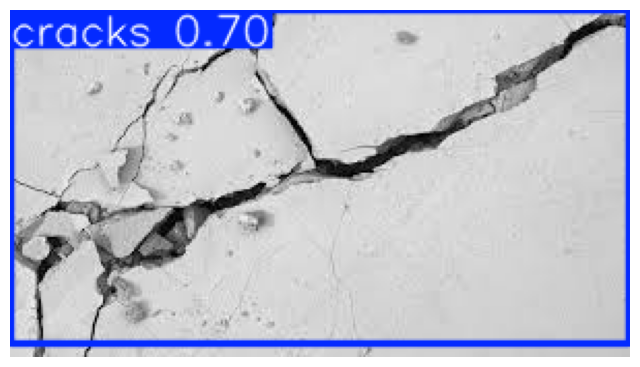

<Figure size 640x480 with 0 Axes>

In [ ]:
imgs_teste_caminho = glob.glob(f"{pasta_img_pred}/*.png")
imgs_teste_caminho += glob.glob(f"{pasta_img_pred}/*.jpg")
imgs_teste_caminho += glob.glob(f"{pasta_img_pred}/*.jpeg")

# test_images = glob.glob(f"{df_caminho}/test/images/*.jpg")

# if test_images:
#     random_test_image = random.choice(test_images)
#     imgs_teste_caminho.append(random_test_image)

print(imgs_teste_caminho)
# Fazer as predições
preds = [melhor_modelo.predict(img_path)[0] for img_path in imgs_teste_caminho]

# Plotar as imagens com suas bounding boxes usando o método nativo do YOLO
plt.figure(figsize=(18, 6))
for img_path in imgs_teste_caminho:
    print(f"\nArquivo: {os.path.basename(img_path)}")

    pred = melhor_modelo.predict(img_path, verbose=False)[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(pred.plot()[:, :, ::-1])
    plt.axis("off")
    plt.show()

plt.tight_layout()
plt.show()

# Predição Modelo Da Ultima Epoca


['/content/imagens_teste/rachadura.jpeg']

image 1/1 /content/imagens_teste/rachadura.jpeg: 96x160 1 cracks, 19.9ms
Speed: 0.5ms preprocess, 19.9ms inference, 0.3ms postprocess per image at shape (1, 3, 96, 160)

Arquivo: rachadura.jpeg


<Figure size 1800x600 with 0 Axes>

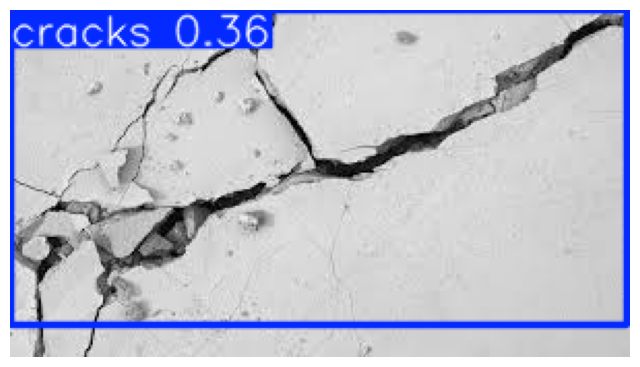

<Figure size 640x480 with 0 Axes>

In [ ]:
imgs_teste_caminho = glob.glob(f"{pasta_img_pred}/*.png")
imgs_teste_caminho += glob.glob(f"{pasta_img_pred}/*.jpg")
imgs_teste_caminho += glob.glob(f"{pasta_img_pred}/*.jpeg")

# test_images = glob.glob(f"{df_caminho}/test/images/*.jpg")

# if test_images:
#     random_test_image = random.choice(test_images)
#     imgs_teste_caminho.append(random_test_image)

print(imgs_teste_caminho)
# Fazer as predições
preds = [ultimo_modelo.predict(img_path)[0] for img_path in imgs_teste_caminho]

# Plotar as imagens com suas bounding boxes usando o método nativo do YOLO
plt.figure(figsize=(18, 6))
for img_path in imgs_teste_caminho:
    print(f"\nArquivo: {os.path.basename(img_path)}")

    pred = ultimo_modelo.predict(img_path, verbose=False)[0]

    plt.figure(figsize=(8, 8))
    plt.imshow(pred.plot()[:, :, ::-1])
    plt.axis("off")
    plt.show()

plt.tight_layout()
plt.show()